SVM WITH DIFFERENT KERNELS

DATASET 1: LINEARLY SEPARABLE
Linear Kernel:
  Train accuracy: 0.9857
  Test accuracy: 0.9667
  # Support vectors: 13 out of 140
  % Support vectors: 9.3%

DATASET 2: CIRCLES (Non-linear)
Linear Kernel (wrong for circles):
  Train accuracy: 0.5929
  Test accuracy: 0.4667
  ✗ Can't separate circles with straight line!

RBF Kernel (perfect for circles):
  Train accuracy: 0.9929
  Test accuracy: 0.9833
  # Support vectors: 43
  ✓ RBF captures circular pattern!

DATASET 3: MOONS (Non-linear)
Polynomial Kernel (degree=3):
  Train accuracy: 0.9143
  Test accuracy: 0.9500

RBF Kernel:
  Train accuracy: 1.0000
  Test accuracy: 0.9833


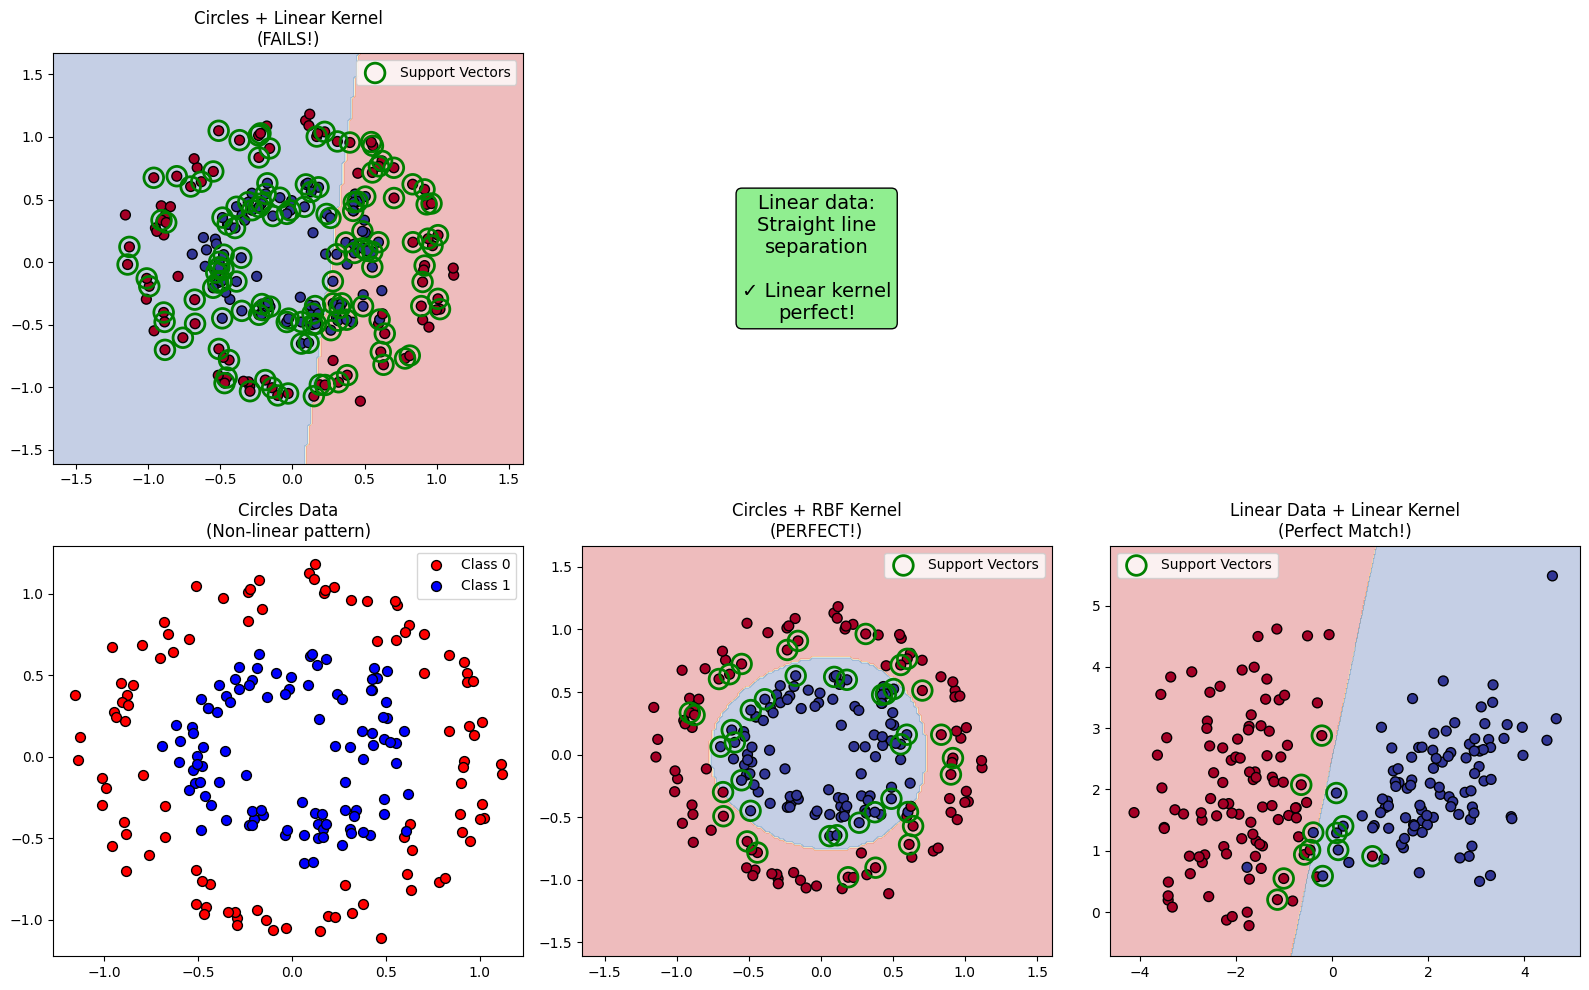


✓ Visualization complete!

KEY OBSERVATIONS:
  • Linear kernel: Works ONLY for linearly separable data
  • RBF kernel: Works for complex non-linear patterns
  • Support vectors: Only points near boundary matter!
  • Kernel trick: Enables non-linear boundaries efficiently


In [13]:
print("=" * 60)
print("SVM WITH DIFFERENT KERNELS")
print("=" * 60)

# WHAT IS AN SVM?
# A Support Vector Machine (SVM) finds the WIDEST possible "street"
# (margin) between two classes. The goal is not just any boundary —
# it's the one that keeps both classes as far apart as possible.
#
# WHAT IS A KERNEL?
# Sometimes classes can't be separated by a straight line (they're
# "non-linearly separable"). A kernel is a mathematical trick that
# transforms data into a higher dimension where a straight line CAN
# separate them — without actually doing the expensive computation.
#
# Think of it like this: red and blue balls mixed together on a table
# can't be separated by a ruler. But if you flip the table and the balls
# fly up, at some height the reds are above the blues — a flat plane
# separates them. That's what kernels do (virtually).
#
# Three common kernels:
#   linear: just a straight line / flat plane (no transformation)
#   rbf   : "Radial Basis Function" — handles circular/blob patterns
#   poly  : polynomial curves — handles crescent/wave patterns

import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_circles, make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ============================================
# DATASET 1: LINEAR (Linearly Separable)
# ============================================
# make_classification with class_sep=2.0 creates two well-separated blobs.
# A straight line should cleanly divide them — ideal for linear SVM.

print("\n" + "=" * 60)
print("DATASET 1: LINEARLY SEPARABLE")
print("=" * 60)

X_linear, y_linear = make_classification(
    n_samples=200,
    n_features=2,       # 2 features so we can plot it
    n_redundant=0,      # no noisy/duplicate features
    n_informative=2,    # both features are genuinely useful
    n_clusters_per_class=1,
    class_sep=2.0,      # high separation → classes are far apart
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_linear, y_linear, test_size=0.3, random_state=42
)

# C=1.0 is a balanced regularization strength (explained more in the next cell).
svm_linear = svm.SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)

acc_train = svm_linear.score(X_train, y_train)
acc_test = svm_linear.score(X_test, y_test)

print(f"Linear Kernel:")
print(f"  Train accuracy: {acc_train:.4f}")
print(f"  Test accuracy: {acc_test:.4f}")
# Support vectors are the data points that sit right on or inside the margin.
# They are the ONLY points that define the decision boundary — all other points
# could be removed and the boundary wouldn't change.
print(f"  # Support vectors: {len(svm_linear.support_vectors_)} out of {len(X_train)}")
print(f"  % Support vectors: {100*len(svm_linear.support_vectors_)/len(X_train):.1f}%")

# ============================================
# DATASET 2: CIRCLES (Non-linear)
# ============================================
# make_circles creates two concentric rings — one inside the other.
# No straight line can separate inner ring from outer ring.
# A linear kernel will fail; RBF will succeed.

print("\n" + "=" * 60)
print("DATASET 2: CIRCLES (Non-linear)")
print("=" * 60)

X_circles, y_circles = make_circles(
    n_samples=200,
    noise=0.1,   # small amount of random jitter on the circle edges
    factor=0.5,  # inner circle is 50% the radius of the outer circle
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_circles, y_circles, test_size=0.3, random_state=42
)

# First, try the wrong kernel just to see it fail.
svm_linear_circles = svm.SVC(kernel='linear', C=1.0)
svm_linear_circles.fit(X_train, y_train)

print(f"Linear Kernel (wrong for circles):")
print(f"  Train accuracy: {svm_linear_circles.score(X_train, y_train):.4f}")
print(f"  Test accuracy: {svm_linear_circles.score(X_test, y_test):.4f}")
print(f"  ✗ Can't separate circles with straight line!")

# Now try RBF. gamma=1.0 controls how far each point's influence reaches
# (higher gamma = tighter influence = more complex boundary).
svm_rbf_circles = svm.SVC(kernel='rbf', C=1.0, gamma=1.0)
svm_rbf_circles.fit(X_train, y_train)

print(f"\nRBF Kernel (perfect for circles):")
print(f"  Train accuracy: {svm_rbf_circles.score(X_train, y_train):.4f}")
print(f"  Test accuracy: {svm_rbf_circles.score(X_test, y_test):.4f}")
print(f"  # Support vectors: {len(svm_rbf_circles.support_vectors_)}")
print(f"  ✓ RBF captures circular pattern!")

# ============================================
# DATASET 3: MOONS (Non-linear)
# ============================================
# make_moons creates two interleaving crescent shapes.
# Again, non-linearly separable — neither kernel is "obviously" best here,
# so we try both polynomial and RBF.

print("\n" + "=" * 60)
print("DATASET 3: MOONS (Non-linear)")
print("=" * 60)

X_moons, y_moons = make_moons(
    n_samples=200,
    noise=0.1,    # small noise to make it more realistic
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42
)

# Polynomial kernel: fits degree-3 (cubic) curves.
# Can handle crescent shapes but may be sensitive to degree choice.
svm_poly = svm.SVC(kernel='poly', degree=3, C=1.0)
svm_poly.fit(X_train, y_train)

print(f"Polynomial Kernel (degree=3):")
print(f"  Train accuracy: {svm_poly.score(X_train, y_train):.4f}")
print(f"  Test accuracy: {svm_poly.score(X_test, y_test):.4f}")

# gamma='scale' automatically sets gamma = 1 / (n_features × X.var())
# which is usually a safe default when you haven't tuned gamma yet.
svm_rbf_moons = svm.SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf_moons.fit(X_train, y_train)

print(f"\nRBF Kernel:")
print(f"  Train accuracy: {svm_rbf_moons.score(X_train, y_train):.4f}")
print(f"  Test accuracy: {svm_rbf_moons.score(X_test, y_test):.4f}")

# ============================================
# VISUALIZATION
# ============================================
# This helper function fills the background with the model's predicted class
# (using a color mesh) so you can visually see the decision boundary shape.
# Green circles mark the support vectors — the critical points on the margin.

def plot_svm_decision_boundary(X, y, model, title):
    """Plot SVM decision boundary"""
    h = 0.02  # mesh resolution — smaller = smoother but slower

    # Build a dense grid of points covering the data range.
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    
    # Predict the class for every point in the grid.
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Color the background by predicted class.
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    # Overlay the actual data points.
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, 
                edgecolors='black', s=50)
    
    # Highlight support vectors with large green circles.
    plt.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=200, linewidth=2, facecolors='none',
                edgecolors='green', label='Support Vectors')
    
    plt.title(title)
    plt.legend()

# Create a 2×3 grid of subplots to show all three datasets and kernels.
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Linear data
plot_svm_decision_boundary(X_linear, y_linear, svm_linear, 
                           'Linear Data + Linear Kernel\n(Perfect Match!)')
plt.sca(axes[0, 0])
plt.gca().set_aspect('auto')

axes[0, 1].text(0.5, 0.5, 'Linear data:\nStraight line\nseparation\n\n✓ Linear kernel\nperfect!',
                ha='center', va='center', fontsize=14, 
                bbox=dict(boxstyle='round', facecolor='lightgreen'))
axes[0, 1].axis('off')

axes[0, 2].axis('off')

# Row 2: Circular data — showing the linear kernel failing vs RBF succeeding.
axes[1, 0].scatter(X_circles[y_circles==0, 0], X_circles[y_circles==0, 1], 
                   c='red', label='Class 0', s=50, edgecolors='black')
axes[1, 0].scatter(X_circles[y_circles==1, 0], X_circles[y_circles==1, 1],
                   c='blue', label='Class 1', s=50, edgecolors='black')
axes[1, 0].set_title('Circles Data\n(Non-linear pattern)')
axes[1, 0].legend()

plot_svm_decision_boundary(X_circles, y_circles, svm_linear_circles,
                           'Circles + Linear Kernel\n(FAILS!)')
plt.sca(axes[1, 1])

plot_svm_decision_boundary(X_circles, y_circles, svm_rbf_circles,
                           'Circles + RBF Kernel\n(PERFECT!)')
plt.sca(axes[1, 2])

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")
print("\nKEY OBSERVATIONS:")
print("  • Linear kernel: Works ONLY for linearly separable data")
print("  • RBF kernel: Works for complex non-linear patterns")
print("  • Support vectors: Only points near boundary matter!")
print("  • Kernel trick: Enables non-linear boundaries efficiently")

SVM HYPERPARAMETER TUNING
Training samples: 350
Test samples: 150

EFFECT OF C PARAMETER


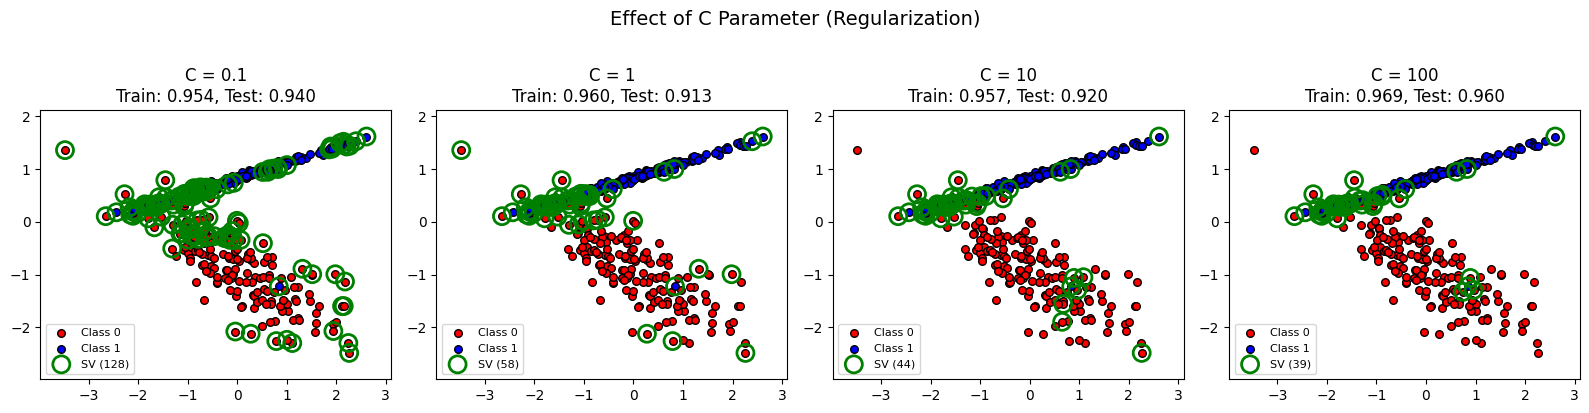


OBSERVATIONS:
  C = 0.1 (soft):  Many support vectors, simple boundary
  C = 1.0:         Balanced
  C = 10:          Fewer support vectors, more complex
  C = 100 (hard):  Very few support vectors, complex boundary

EFFECT OF GAMMA PARAMETER (RBF)


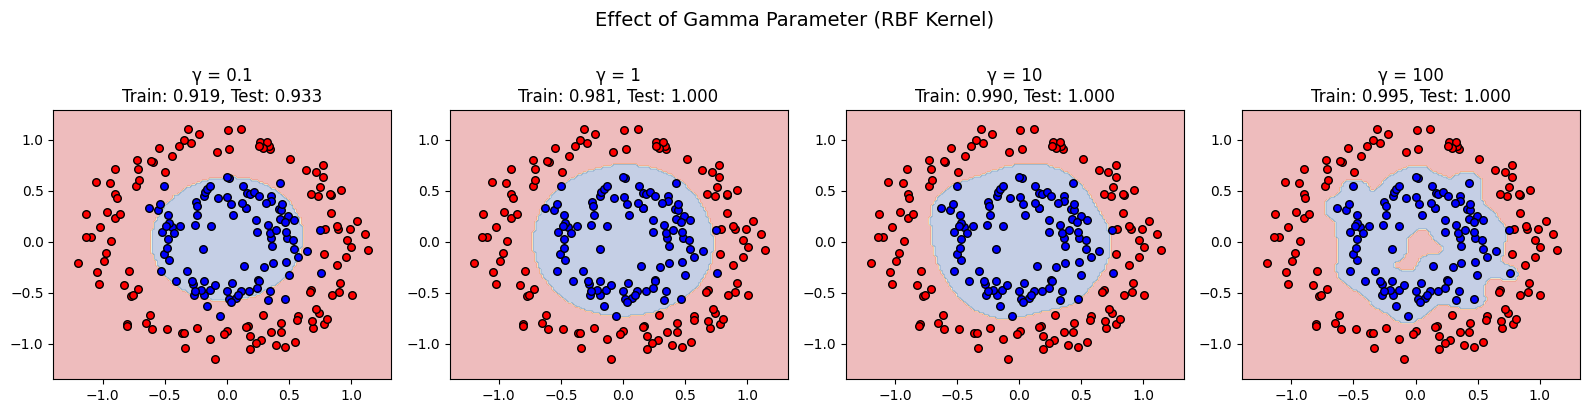


OBSERVATIONS:
  γ = 0.1:   Smooth boundary, may underfit
  γ = 1:     Balanced
  γ = 10:    Complex boundary, good fit
  γ = 100:   Very wiggly, overfits

GRID SEARCH: FINDING OPTIMAL C AND GAMMA
Searching through 4 × 5 = 20 combinations...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Best CV score: 0.9457

Final Performance:
  Train accuracy: 0.9743
  Test accuracy: 0.9733
  Gap: 0.0010
  # Support vectors: 40 / 350
  % Support vectors: 11.4%

GRID SEARCH HEATMAP


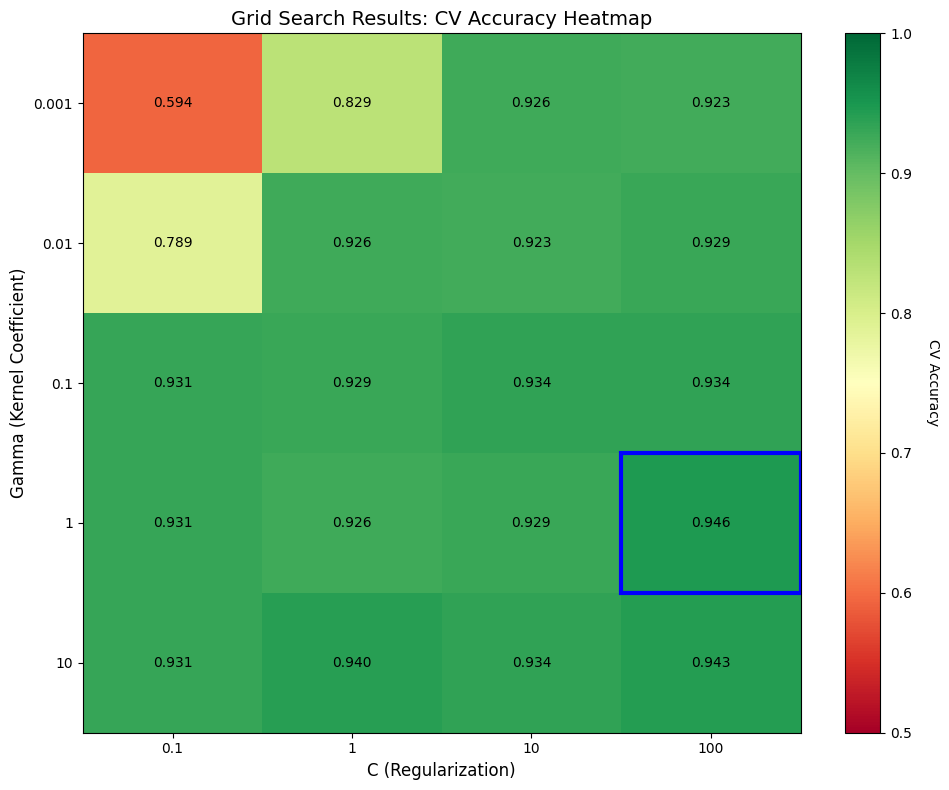


✓ Grid search complete!
  Best combination: C=100, γ=1
  Marked with blue box in heatmap


In [14]:
print("=" * 60)
print("SVM HYPERPARAMETER TUNING")
print("=" * 60)

# SVM has two key hyperparameters to tune:
#
# C — Regularization strength (controls the margin / error tradeoff):
#   - Small C (soft margin): allows more misclassifications but creates
#     a wider, smoother margin. More tolerant of noise — less overfitting.
#   - Large C (hard margin): tries to classify EVERY training point correctly.
#     Narrow margin, complex boundary — risks overfitting.
#   Think of C as "how much do you punish mistakes?"
#
# gamma — RBF kernel: controls how far each point's influence reaches:
#   - Small gamma: each point influences a large area → smooth, broad boundary.
#   - Large gamma: each point only influences nearby area → wiggly, tight boundary.
#   Think of gamma as "how far does each training point 'see'?"

import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# ============================================
# GENERATE DATA
# ============================================

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,   # moderate separation — not trivially easy
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# CRITICAL: Always scale features for SVM!
# SVM uses distances between points. If one feature has range 0-1000
# and another has range 0-1, the first dominates all distance calculations.
# StandardScaler transforms each feature to mean=0 and std=1.
#
# IMPORTANT: fit_transform on TRAIN only, then transform (not fit) on TEST.
# If you fit on test data, you leak information about the test distribution.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std from train, apply
X_test_scaled = scaler.transform(X_test)          # apply same transform (no refit)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# ============================================
# VISUALIZE C AND GAMMA EFFECTS
# ============================================

print("\n" + "=" * 60)
print("EFFECT OF C PARAMETER")
print("=" * 60)

# We'll train 4 models with the same kernel but different C values
# to see how the margin and support vectors change.
C_values = [0.1, 1, 10, 100]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, C in enumerate(C_values):
    svm_model = svm.SVC(kernel='rbf', C=C, gamma='scale')
    svm_model.fit(X_train_scaled, y_train)
    
    train_acc = svm_model.score(X_train_scaled, y_train)
    test_acc = svm_model.score(X_test_scaled, y_test)
    n_support = len(svm_model.support_vectors_)  # fewer SVs = simpler model
    
    axes[idx].scatter(X_train_scaled[y_train==0, 0], 
                     X_train_scaled[y_train==0, 1],
                     c='red', s=30, edgecolors='black', label='Class 0')
    axes[idx].scatter(X_train_scaled[y_train==1, 0],
                     X_train_scaled[y_train==1, 1],
                     c='blue', s=30, edgecolors='black', label='Class 1')
    
    # Green circles around support vectors — watch how this count changes with C.
    axes[idx].scatter(svm_model.support_vectors_[:, 0],
                     svm_model.support_vectors_[:, 1],
                     s=150, linewidth=2, facecolors='none',
                     edgecolors='green', label=f'SV ({n_support})')
    
    axes[idx].set_title(f'C = {C}\nTrain: {train_acc:.3f}, Test: {test_acc:.3f}')
    axes[idx].legend(fontsize=8)
    axes[idx].set_xlim(X_train_scaled[:, 0].min()-0.5, X_train_scaled[:, 0].max()+0.5)
    axes[idx].set_ylim(X_train_scaled[:, 1].min()-0.5, X_train_scaled[:, 1].max()+0.5)

plt.suptitle('Effect of C Parameter (Regularization)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nOBSERVATIONS:")
print("  C = 0.1 (soft):  Many support vectors, simple boundary")
print("  C = 1.0:         Balanced")
print("  C = 10:          Fewer support vectors, more complex")
print("  C = 100 (hard):  Very few support vectors, complex boundary")

# ============================================
# GAMMA EFFECT (RBF Kernel)
# ============================================

print("\n" + "=" * 60)
print("EFFECT OF GAMMA PARAMETER (RBF)")
print("=" * 60)

# Circles data makes the gamma effect very visible:
# small gamma → broad smooth curve, large gamma → tight wiggly boundary.
X_circles, y_circles = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_circles, y_circles, test_size=0.3, random_state=42
)

gamma_values = [0.1, 1, 10, 100]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, gamma in enumerate(gamma_values):
    svm_model = svm.SVC(kernel='rbf', C=1.0, gamma=gamma)
    svm_model.fit(X_train_c, y_train_c)
    
    train_acc = svm_model.score(X_train_c, y_train_c)
    test_acc = svm_model.score(X_test_c, y_test_c)
    
    # Build a mesh to visualize the decision boundary shape.
    h = 0.02
    x_min, x_max = X_train_c[:, 0].min() - 0.2, X_train_c[:, 0].max() + 0.2
    y_min, y_max = X_train_c[:, 1].min() - 0.2, X_train_c[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    axes[idx].scatter(X_train_c[y_train_c==0, 0], X_train_c[y_train_c==0, 1],
                     c='red', s=30, edgecolors='black')
    axes[idx].scatter(X_train_c[y_train_c==1, 0], X_train_c[y_train_c==1, 1],
                     c='blue', s=30, edgecolors='black')
    
    # Watch how the boundary goes from smooth circle (γ=0.1)
    # to an overfitted blob-map (γ=100).
    axes[idx].set_title(f'γ = {gamma}\nTrain: {train_acc:.3f}, Test: {test_acc:.3f}')

plt.suptitle('Effect of Gamma Parameter (RBF Kernel)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nOBSERVATIONS:")
print("  γ = 0.1:   Smooth boundary, may underfit")
print("  γ = 1:     Balanced")
print("  γ = 10:    Complex boundary, good fit")
print("  γ = 100:   Very wiggly, overfits")

# ============================================
# GRID SEARCH FOR OPTIMAL C AND GAMMA
# ============================================
# Rather than manually trying combinations, GridSearchCV exhaustively
# tests every (C, gamma) pair using cross-validation (cv=5 means
# 5-fold CV: train on 80%, validate on 20%, repeat 5 times).
# It returns the combination with the highest average validation accuracy.

print("\n" + "=" * 60)
print("GRID SEARCH: FINDING OPTIMAL C AND GAMMA")
print("=" * 60)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(
    svm.SVC(),
    param_grid,
    cv=5,                  # 5-fold cross-validation
    scoring='accuracy',
    verbose=1,
    n_jobs=-1              # use all CPU cores to parallelize the search
)

print("Searching through 4 × 5 = 20 combinations...")
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Evaluate the winner on the held-out test set.
best_model = grid_search.best_estimator_
train_acc = best_model.score(X_train_scaled, y_train)
test_acc = best_model.score(X_test_scaled, y_test)

print(f"\nFinal Performance:")
print(f"  Train accuracy: {train_acc:.4f}")
print(f"  Test accuracy: {test_acc:.4f}")
print(f"  Gap: {train_acc - test_acc:.4f}")
print(f"  # Support vectors: {len(best_model.support_vectors_)} / {len(X_train)}")
print(f"  % Support vectors: {100*len(best_model.support_vectors_)/len(X_train):.1f}%")

# ============================================
# VISUALIZE GRID SEARCH RESULTS
# ============================================
# A heatmap where each cell = average CV accuracy for that (C, gamma) combo.
# Green = high accuracy, red = low. The blue rectangle marks the best combo.
# This lets you see at a glance which region of the parameter space works well.

print("\n" + "=" * 60)
print("GRID SEARCH HEATMAP")
print("=" * 60)

results = grid_search.cv_results_
C_values = param_grid['C']
gamma_values = param_grid['gamma']

# Build a 2D matrix of scores indexed by [gamma_idx, C_idx].
scores = np.zeros((len(gamma_values), len(C_values)))

for i, gamma in enumerate(gamma_values):
    for j, C in enumerate(C_values):
        mask = (results['param_C'] == C) & (results['param_gamma'] == gamma)
        if np.any(mask):
            scores[i, j] = results['mean_test_score'][mask][0]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(scores, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)

ax.set_xticks(np.arange(len(C_values)))
ax.set_yticks(np.arange(len(gamma_values)))
ax.set_xticklabels(C_values)
ax.set_yticklabels(gamma_values)

ax.set_xlabel('C (Regularization)', fontsize=12)
ax.set_ylabel('Gamma (Kernel Coefficient)', fontsize=12)
ax.set_title('Grid Search Results: CV Accuracy Heatmap', fontsize=14)

# Annotate each cell with the numeric accuracy.
for i in range(len(gamma_values)):
    for j in range(len(C_values)):
        text = ax.text(j, i, f'{scores[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=10)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('CV Accuracy', rotation=270, labelpad=20)

# Draw a blue box around the winning combination.
best_C = grid_search.best_params_['C']
best_gamma = grid_search.best_params_['gamma']
best_i = gamma_values.index(best_gamma)
best_j = C_values.index(best_C)
ax.add_patch(plt.Rectangle((best_j-0.5, best_i-0.5), 1, 1, 
                           fill=False, edgecolor='blue', linewidth=3))

plt.tight_layout()
plt.show()

print("\n✓ Grid search complete!")
print(f"  Best combination: C={best_C}, γ={best_gamma}")
print(f"  Marked with blue box in heatmap")

In [15]:
print("\n" + "=" * 60)
print("WHY SCALING IS CRITICAL FOR SVM")
print("=" * 60)

# WHY DOES SCALING MATTER FOR SVM?
#
# SVM computes distances between data points to find the margin.
# The RBF kernel formula is: K(x, x') = exp(-γ · ||x - x'||²)
# where ||x - x'||² is the squared Euclidean distance between two points.
#
# If Feature A ranges from 0 to 1000 and Feature B ranges from 0 to 1,
# then Feature A completely dominates the distance calculation.
# SVM essentially "ignores" Feature B — even if B is more informative!
#
# After scaling (e.g., StandardScaler), both features contribute equally.
# This cell demonstrates the problem with a deliberately extreme example.

np.random.seed(42)
X_unscaled = np.random.randn(200, 2)
X_unscaled[:, 0] = X_unscaled[:, 0] * 1000  # Feature 1: huge scale (~-3000 to +3000)
X_unscaled[:, 1] = X_unscaled[:, 1] * 1     # Feature 2: normal scale (~-3 to +3)

# The true signal uses BOTH features equally — so scaling should help.
y = (X_unscaled[:, 0] + X_unscaled[:, 1] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_unscaled, y, test_size=0.3, random_state=42
)

print("Feature ranges BEFORE scaling:")
print(f"  Feature 0: [{X_train[:, 0].min():.1f}, {X_train[:, 0].max():.1f}]")
print(f"  Feature 1: [{X_train[:, 1].min():.1f}, {X_train[:, 1].max():.1f}]")

# Train WITHOUT scaling — SVM will effectively ignore Feature 1.
svm_no_scale = svm.SVC(kernel='rbf', C=1.0, gamma='scale')
svm_no_scale.fit(X_train, y_train)

no_scale_train = svm_no_scale.score(X_train, y_train)
no_scale_test = svm_no_scale.score(X_test, y_test)

print(f"\nWITHOUT scaling:")
print(f"  Train: {no_scale_train:.4f}")
print(f"  Test: {no_scale_test:.4f}")

# StandardScaler: for each feature, subtract the mean and divide by std.
# Result: every feature has mean≈0 and std≈1 → equal contribution to distances.
#
# fit_transform(X_train): compute mean & std from TRAINING data, then apply.
# transform(X_test): apply the SAME mean & std (don't relearn from test data!).
# Using test statistics would "leak" test information into training — a common mistake.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature ranges AFTER scaling:")
print(f"  Feature 0: [{X_train_scaled[:, 0].min():.1f}, {X_train_scaled[:, 0].max():.1f}]")
print(f"  Feature 1: [{X_train_scaled[:, 1].min():.1f}, {X_train_scaled[:, 1].max():.1f}]")

# Train WITH scaling — now both features contribute fairly.
svm_with_scale = svm.SVC(kernel='rbf', C=1.0, gamma='scale')
svm_with_scale.fit(X_train_scaled, y_train)

with_scale_train = svm_with_scale.score(X_train_scaled, y_train)
with_scale_test = svm_with_scale.score(X_test_scaled, y_test)

print(f"\nWITH scaling:")
print(f"  Train: {with_scale_train:.4f}")
print(f"  Test: {with_scale_test:.4f}")

print("\n" + "=" * 60)
print("WHY THIS MATTERS:")
print("=" * 60)
print("""
SVM uses DISTANCES between points:
- Feature with large scale (0-1000) dominates
- Feature with small scale (0-1) ignored
- RBF kernel: exp(-γ||x-x'||²)
  - If ||x-x'|| large → kernel ≈ 0
  - All points look dissimilar!

ALWAYS scale features for SVM:
✓ StandardScaler (mean=0, std=1) ← Most common
✓ MinMaxScaler (range 0-1)
✓ RobustScaler (for outliers)

Decision Trees/Random Forests: DON'T need scaling
SVM: MUST scale!
""")


WHY SCALING IS CRITICAL FOR SVM
Feature ranges BEFORE scaling:
  Feature 0: [-3241.3, 2314.7]
  Feature 1: [-2.0, 2.7]

WITHOUT scaling:
  Train: 0.9857
  Test: 0.9333

Feature ranges AFTER scaling:
  Feature 0: [-3.4, 2.4]
  Feature 1: [-2.2, 2.9]

WITH scaling:
  Train: 0.9714
  Test: 0.9167

WHY THIS MATTERS:

SVM uses DISTANCES between points:
- Feature with large scale (0-1000) dominates
- Feature with small scale (0-1) ignored
- RBF kernel: exp(-γ||x-x'||²)
  - If ||x-x'|| large → kernel ≈ 0
  - All points look dissimilar!

ALWAYS scale features for SVM:
✓ StandardScaler (mean=0, std=1) ← Most common
✓ MinMaxScaler (range 0-1)
✓ RobustScaler (for outliers)

Decision Trees/Random Forests: DON'T need scaling
SVM: MUST scale!




SVM vs XGBOOST vs RANDOM FOREST vs LOGISTIC REGRESSION

1. LOGISTIC REGRESSION
Training time: 0.012s
Train accuracy: 0.8071
Test accuracy: 0.8167
Gap: -0.0095

2. SVM (RBF Kernel)
Training time: 0.053s
Train accuracy: 0.9764
Test accuracy: 0.9650
Gap: 0.0114
# Support vectors: 523 / 1400
% Support vectors: 37.4%

3. RANDOM FOREST
Training time: 0.291s
Train accuracy: 1.0000
Test accuracy: 0.9067
Gap: 0.0933

4. XGBOOST
Training time: 0.129s
Train accuracy: 0.9714
Test accuracy: 0.8967
Gap: 0.0748

COMPLETE COMPARISON
              Model  Train Time  Train Acc  Test Acc     Gap
Logistic Regression      0.0120     0.8071    0.8167 -0.0095
          SVM (RBF)      0.0529     0.9764    0.9650  0.0114
      Random Forest      0.2905     1.0000    0.9067  0.0933
            XGBoost      0.1291     0.9714    0.8967  0.0748


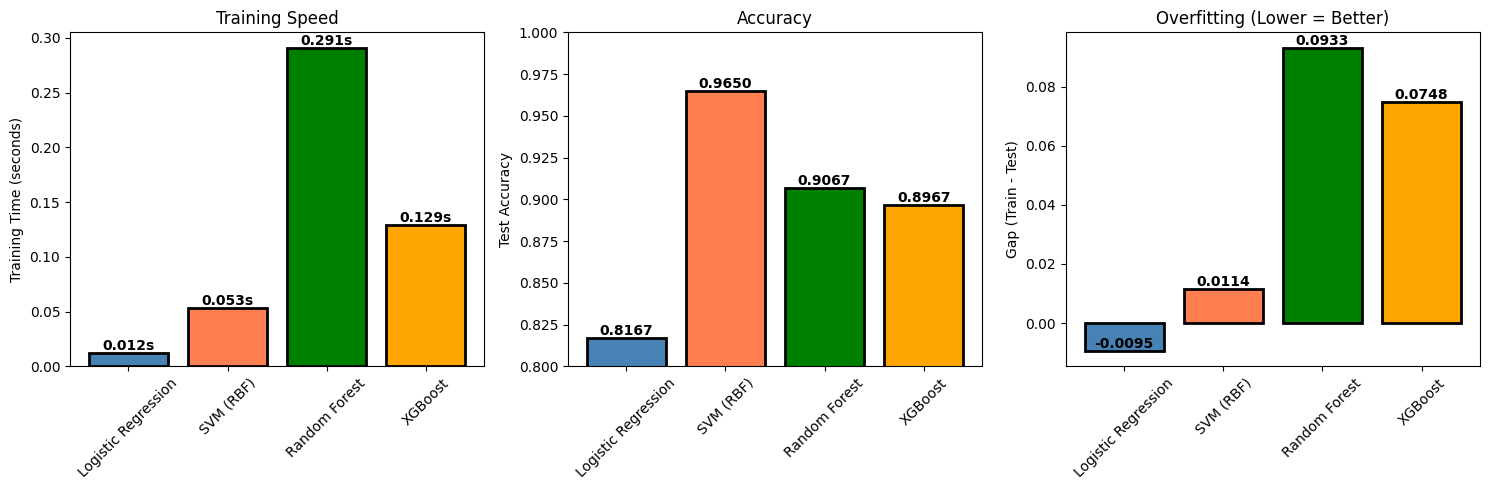


✓ Comparison complete!


In [16]:
print("\n" + "=" * 60)
print("SVM vs XGBOOST vs RANDOM FOREST vs LOGISTIC REGRESSION")
print("=" * 60)

# Now we put SVM head-to-head against the other algorithms we've learned.
# Key things to watch:
#   - Training time: SVM is notoriously slow on large datasets (O(n²) to O(n³))
#   - Accuracy: all models should be competitive on a well-formed dataset
#   - Overfitting gap: how much does train accuracy exceed test accuracy?
#   - Support vectors (SVM only): what % of training points are on the margin?

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import time

# Generate a moderately challenging dataset:
# 2000 samples, 20 features (15 informative + 5 redundant noise features).
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale for models that need it. SVM and Logistic Regression are
# distance/gradient-based — they require scaling.
# Random Forest and XGBoost use decision trees — they don't.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

# ============================================
# 1. LOGISTIC REGRESSION
# ============================================
# The simplest baseline: fits a linear boundary.
# Fast and interpretable, but limited to linearly separable patterns.
# max_iter=1000 allows the solver more steps to converge on complex data.

print("\n" + "=" * 60)
print("1. LOGISTIC REGRESSION")
print("=" * 60)

start = time.time()
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_time = time.time() - start

lr_train = lr.score(X_train_scaled, y_train)
lr_test = lr.score(X_test_scaled, y_test)

print(f"Training time: {lr_time:.3f}s")
print(f"Train accuracy: {lr_train:.4f}")
print(f"Test accuracy: {lr_test:.4f}")
print(f"Gap: {lr_train - lr_test:.4f}")

results.append({
    'Model': 'Logistic Regression',
    'Train Time': lr_time,
    'Train Acc': lr_train,
    'Test Acc': lr_test,
    'Gap': lr_train - lr_test
})

# ============================================
# 2. SVM (RBF Kernel)
# ============================================
# SVM with RBF kernel handles non-linear boundaries.
# On large datasets it becomes slow because training complexity is
# roughly O(n² to n³) — much worse than tree-based methods.

print("\n" + "=" * 60)
print("2. SVM (RBF Kernel)")
print("=" * 60)

start = time.time()
svm_model = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_time = time.time() - start

svm_train = svm_model.score(X_train_scaled, y_train)
svm_test = svm_model.score(X_test_scaled, y_test)

print(f"Training time: {svm_time:.3f}s")
print(f"Train accuracy: {svm_train:.4f}")
print(f"Test accuracy: {svm_test:.4f}")
print(f"Gap: {svm_train - svm_test:.4f}")
# If many training points become support vectors, the model may be struggling
# to find a clear margin — could indicate a hard problem or need for tuning.
print(f"# Support vectors: {len(svm_model.support_vectors_)} / {len(X_train)}")
print(f"% Support vectors: {100*len(svm_model.support_vectors_)/len(X_train):.1f}%")

results.append({
    'Model': 'SVM (RBF)',
    'Train Time': svm_time,
    'Train Acc': svm_train,
    'Test Acc': svm_test,
    'Gap': svm_train - svm_test
})

# ============================================
# 3. RANDOM FOREST
# ============================================
# Builds many deep trees in parallel, averaging their predictions.
# Does NOT need scaling — decision trees split on thresholds, not distances.
# n_jobs=-1 enables all CPU cores for parallel tree building.

print("\n" + "=" * 60)
print("3. RANDOM FOREST")
print("=" * 60)

start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)   # raw (unscaled) data — intentional!
rf_time = time.time() - start

rf_train = rf.score(X_train, y_train)
rf_test = rf.score(X_test, y_test)

print(f"Training time: {rf_time:.3f}s")
print(f"Train accuracy: {rf_train:.4f}")
print(f"Test accuracy: {rf_test:.4f}")
print(f"Gap: {rf_train - rf_test:.4f}")

results.append({
    'Model': 'Random Forest',
    'Train Time': rf_time,
    'Train Acc': rf_train,
    'Test Acc': rf_test,
    'Gap': rf_train - rf_test
})

# ============================================
# 4. XGBOOST
# ============================================
# Sequential gradient boosting — each tree corrects the previous one's errors.
# Also does NOT need scaling (tree-based splits).

print("\n" + "=" * 60)
print("4. XGBOOST")
print("=" * 60)

start = time.time()
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)  # raw data — no scaling needed
xgb_time = time.time() - start

xgb_train = xgb_model.score(X_train, y_train)
xgb_test = xgb_model.score(X_test, y_test)

print(f"Training time: {xgb_time:.3f}s")
print(f"Train accuracy: {xgb_train:.4f}")
print(f"Test accuracy: {xgb_test:.4f}")
print(f"Gap: {xgb_train - xgb_test:.4f}")

results.append({
    'Model': 'XGBoost',
    'Train Time': xgb_time,
    'Train Acc': xgb_train,
    'Test Acc': xgb_test,
    'Gap': xgb_train - xgb_test
})

# ============================================
# COMPARISON TABLE
# ============================================

print("\n" + "=" * 60)
print("COMPLETE COMPARISON")
print("=" * 60)

import pandas as pd
df_results = pd.DataFrame(results)
df_results = df_results.round(4)
print(df_results.to_string(index=False))

# ── THREE BAR CHARTS ───────────────────────────────────────────
# Chart 1: Training time — how long each model takes to train.
# Chart 2: Test accuracy — how well each model generalizes.
# Chart 3: Overfitting gap — difference between train and test accuracy.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = [r['Model'] for r in results]
train_times = [r['Train Time'] for r in results]
test_accs = [r['Test Acc'] for r in results]
gaps = [r['Gap'] for r in results]

# Chart 1: Training time (lower = faster).
axes[0].bar(models, train_times, color=['steelblue', 'coral', 'green', 'orange'],
            edgecolor='black', linewidth=2)
axes[0].set_ylabel('Training Time (seconds)')
axes[0].set_title('Training Speed')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(train_times):
    axes[0].text(i, v, f'{v:.3f}s', ha='center', va='bottom', fontweight='bold')

# Chart 2: Test accuracy (higher = better generalization).
axes[1].bar(models, test_accs, color=['steelblue', 'coral', 'green', 'orange'],
            edgecolor='black', linewidth=2)
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_ylim(0.8, 1.0)  # zoom in so differences are visible
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(test_accs):
    axes[1].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Chart 3: Overfitting gap (lower = less overfitting).
axes[2].bar(models, gaps, color=['steelblue', 'coral', 'green', 'orange'],
            edgecolor='black', linewidth=2)
axes[2].set_ylabel('Gap (Train - Test)')
axes[2].set_title('Overfitting (Lower = Better)')
axes[2].tick_params(axis='x', rotation=45)

for i, v in enumerate(gaps):
    axes[2].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Comparison complete!")

In [17]:
print("\n" + "=" * 60)
print("WHEN TO USE SVM: DECISION FRAMEWORK")
print("=" * 60)

# Having seen all four algorithms compete, here's practical guidance
# on when SVM is actually the right tool for the job.
# The short version: SVM shines on small high-dimensional datasets
# (like text or images) but loses to tree methods on large tabular data.

decision_framework = """
┌─────────────────────────────────────────────────┐
│         SVM vs OTHER ALGORITHMS                 │
├─────────────────────────────────────────────────┤
│                                                 │
│  USE SVM WHEN:                                  │
│  ✓ Small-medium dataset (<10,000 samples)       │
│  ✓ High-dimensional data (text, images)         │
│  ✓ Clear margin of separation expected          │
│  ✓ Need theoretically sound approach            │
│  ✓ Feature scaling is acceptable                │
│  ✓ Non-linear boundaries (RBF kernel)           │
│                                                 │
│  USE XGBOOST/RF WHEN:                           │
│  ✓ Large dataset (>10,000 samples)              │
│  ✓ Tabular data with mixed feature types        │
│  ✓ Want best accuracy (competitions)            │
│  ✓ No time for scaling                          │
│  ✓ Feature importance needed                    │
│  ✓ Can afford longer training                   │
│                                                 │
│  USE LINEAR/LOGISTIC REGRESSION WHEN:           │
│  ✓ Need interpretability                        │
│  ✓ Linear relationship suspected                │
│  ✓ Want fastest training                        │
│  ✓ Baseline model                               │
│  ✓ Real-time prediction critical                │
│                                                 │
└─────────────────────────────────────────────────┘

REAL-WORLD USE CASES:

SVM Wins:
- Text classification (spam detection)
- Image classification (face detection)
- Bioinformatics (protein classification)
- Small dataset with clear structure

XGBoost Wins:
- Kaggle competitions (tabular data)
- Click-through rate prediction
- Fraud detection (large scale)
- Recommendation systems

Linear Models Win:
- Risk scoring (need probabilities + interpretability)
- Medical diagnosis (regulatory requirements)
- Quick baselines
- A/B testing (fast iterations)
"""

print(decision_framework)

# ============================================
# PRACTICAL WORKFLOW
# ============================================
# A step-by-step recipe for attacking any new classification problem.
# The key insight: start simple and fast, escalate only if needed.
# Most real problems are solved at Step 3 — you rarely need Step 4.

print("\n" + "=" * 60)
print("RECOMMENDED WORKFLOW FOR NEW PROBLEM")
print("=" * 60)

workflow = """
Step 1: Quick Baseline (5 minutes)
  → Logistic Regression (if classification)
  → Linear Regression (if regression)
  Result: Baseline accuracy

Step 2: Check if Linear Good Enough (1 minute)
  → If accuracy > target: DONE! ✓
  → If not: Continue

Step 3: Try Tree Ensembles (30 minutes)
  → Random Forest (quick, robust)
  → XGBoost (if RF not enough)
  Result: Best tabular accuracy

Step 4: Try SVM (if applicable) (30 minutes)
  → If data <10k samples
  → If text/image data
  → If trees not working well
  Result: Alternative approach

Step 5: Choose Final Model
  → Best test accuracy
  → Deployment constraints (speed, memory)
  → Interpretability requirements

80% of time: XGBoost or RF wins
15% of time: Linear model sufficient
5% of time: SVM for special cases
"""

print(workflow)


WHEN TO USE SVM: DECISION FRAMEWORK

┌─────────────────────────────────────────────────┐
│         SVM vs OTHER ALGORITHMS                 │
├─────────────────────────────────────────────────┤
│                                                 │
│  USE SVM WHEN:                                  │
│  ✓ Small-medium dataset (<10,000 samples)       │
│  ✓ High-dimensional data (text, images)         │
│  ✓ Clear margin of separation expected          │
│  ✓ Need theoretically sound approach            │
│  ✓ Feature scaling is acceptable                │
│  ✓ Non-linear boundaries (RBF kernel)           │
│                                                 │
│  USE XGBOOST/RF WHEN:                           │
│  ✓ Large dataset (>10,000 samples)              │
│  ✓ Tabular data with mixed feature types        │
│  ✓ Want best accuracy (competitions)            │
│  ✓ No time for scaling                          │
│  ✓ Feature importance needed                    │
│  ✓ Can afford longer tra

In [18]:
print("\n" + "=" * 60)
print("COMPLETE SVM PRODUCTION PIPELINE")
print("=" * 60)

# This is a reusable, production-ready SVM template.
# Key feature: we use sklearn's Pipeline to bundle the scaler and the SVM
# into one object. This prevents a common bug where you forget to apply
# the same scaling to new data at prediction time.

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import joblib

# Generate data (replace with your own dataset in practice).
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# STAGE 1: BASELINE
# ============================================
# Start with the simplest kernel (linear) to get a quick baseline.
# If the data is linearly separable, this may be all you need.

print("\nSTAGE 1: Baseline (Linear Kernel)")
print("=" * 60)

svm_linear = svm.SVC(kernel='linear', C=1.0, random_state=42)

# Pipeline chains preprocessing + model into one object.
# Calling pipeline.fit(X_train, y_train):
#   1. Fits StandardScaler on X_train (learns mean & std).
#   2. Transforms X_train with the fitted scaler.
#   3. Fits the SVM on the scaled X_train.
# Calling pipeline.predict(X_test):
#   1. Transforms X_test using the ALREADY-FITTED scaler (no refit!).
#   2. Passes the scaled data to the SVM for prediction.
# This makes it impossible to accidentally forget scaling at inference time.
pipeline_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', svm_linear)
])

pipeline_linear.fit(X_train, y_train)

baseline_train = pipeline_linear.score(X_train, y_train)
baseline_test = pipeline_linear.score(X_test, y_test)

print(f"Train: {baseline_train:.4f}")
print(f"Test: {baseline_test:.4f}")
print(f"Gap: {baseline_train - baseline_test:.4f}")

# ============================================
# STAGE 2: TRY RBF KERNEL
# ============================================
# If the linear kernel isn't good enough, try RBF.
# RBF handles non-linear patterns using the kernel trick —
# it implicitly maps data into a higher-dimensional space.

print("\nSTAGE 2: Try RBF Kernel")
print("=" * 60)

svm_rbf = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

pipeline_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', svm_rbf)
])

pipeline_rbf.fit(X_train, y_train)

rbf_train = pipeline_rbf.score(X_train, y_train)
rbf_test = pipeline_rbf.score(X_test, y_test)

print(f"Train: {rbf_train:.4f}")
print(f"Test: {rbf_test:.4f}")
print(f"Gap: {rbf_train - rbf_test:.4f}")

if rbf_test > baseline_test:
    print("✓ RBF better than linear!")
else:
    print("Linear sufficient!")

# ============================================
# STAGE 3: HYPERPARAMETER TUNING
# ============================================
# Now we use GridSearchCV to find the best C and gamma.
# Note the parameter naming: 'svm__C' means "the C parameter of
# the pipeline step named 'svm'". This double-underscore syntax
# is how you pass hyperparameters into a specific pipeline step.

print("\nSTAGE 3: Hyperparameter Tuning")
print("=" * 60)

param_grid = {
    'svm__C': [0.1, 1, 10],        # regularization strength
    'svm__gamma': [0.001, 0.01, 0.1, 1]  # RBF kernel width
}

# GridSearchCV wraps the entire pipeline — scaling happens inside CV,
# so validation folds are never contaminated by training statistics.
grid_search = GridSearchCV(
    pipeline_rbf,
    param_grid,
    cv=5,               # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# ============================================
# STAGE 4: FINAL EVALUATION
# ============================================
# Evaluate on the test set — this is our honest, unbiased report card.
# We touch the test set ONLY here, never during tuning.

print("\nSTAGE 4: Final Evaluation")
print("=" * 60)

best_model = grid_search.best_estimator_

final_train = best_model.score(X_train, y_train)
final_test = best_model.score(X_test, y_test)

y_pred = best_model.predict(X_test)

print(f"\nFinal Performance:")
print(f"  Train: {final_train:.4f}")
print(f"  Test: {final_test:.4f}")
print(f"  Gap: {final_train - final_test:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================
# STAGE 5: SAVE MODEL
# ============================================
# joblib is the recommended way to save sklearn pipelines.
# We save the ENTIRE pipeline (scaler + SVM) — not just the SVM.
# This way, when you load it later, scaling is applied automatically.
# Also save a JSON metadata file to record key stats alongside the model.

print("\nSTAGE 5: Save Model")
print("=" * 60)

joblib.dump(best_model, 'svm_model.pkl')
print("✓ Model saved to: svm_model.pkl")

metadata = {
    'kernel': grid_search.best_params_.get('svm__kernel', 'rbf'),
    'C': grid_search.best_params_['svm__C'],
    'gamma': grid_search.best_params_['svm__gamma'],
    'test_accuracy': float(final_test),
    # Access the SVM step inside the pipeline via named_steps.
    'n_support_vectors': int(len(best_model.named_steps['svm'].support_vectors_)),
    'n_features': X.shape[1]
}

import json
with open('svm_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ Metadata saved to: svm_metadata.json")

# ============================================
# STAGE 6: LOAD AND USE
# ============================================
# Loading is one line with joblib. Because we saved the pipeline,
# scaling is handled automatically — no need to re-create or re-fit a scaler.
# Just call loaded_model.predict(raw_data) and it works correctly.

print("\nSTAGE 6: Load and Use (Later)")
print("=" * 60)

loaded_model = joblib.load('svm_model.pkl')

# The pipeline handles scaling internally before passing to the SVM.
new_predictions = loaded_model.predict(X_test[:5])
# predict_proba requires probability=True in SVC — check before calling.
new_probabilities = loaded_model.predict_proba(X_test[:5]) if hasattr(loaded_model.named_steps['svm'], 'predict_proba') else None

print(f"Predictions for first 5 test samples: {new_predictions}")

print("\n✓ Complete SVM pipeline finished!")


COMPLETE SVM PRODUCTION PIPELINE

STAGE 1: Baseline (Linear Kernel)
Train: 0.8250
Test: 0.7950
Gap: 0.0300

STAGE 2: Try RBF Kernel
Train: 0.9825
Test: 0.9200
Gap: 0.0625
✓ RBF better than linear!

STAGE 3: Hyperparameter Tuning
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'svm__C': 1, 'svm__gamma': 0.1}
Best CV score: 0.9575

STAGE 4: Final Evaluation

Final Performance:
  Train: 0.9950
  Test: 0.9600
  Gap: 0.0350

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       112
           1       0.93      0.99      0.96        88

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200


STAGE 5: Save Model
✓ Model saved to: svm_model.pkl
✓ Metadata saved to: svm_metadata.json

STAGE 6: Load and Use (Later)
Predictions for first 5 test samples: [0 0 1 0 1]

✓ Complete SVM pipeline